In [55]:
import pandas as pd, numpy as np
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor

df = pd.read_csv("data.csv")
data = df.copy().drop_duplicates()                      # fixed: ()

In [56]:
# --- job title ---
data = data.dropna(subset=['job_title'])
data['job_title'] = data['job_title'].replace({"data sci": "data scientist"})

In [57]:
# --- ownership (3% missing): mode is fine ---
data['ownership'] = data['ownership'].fillna(data['ownership'].mode()[0])

In [58]:
# --- salary: cap outliers first, then fill with MEDIAN by job title ---
for c in ['min_salary', 'max_salary']:
    data.loc[data[c] <= 1000, c] = np.nan               # zeros / 1 are errors
    cap = data[c].quantile(0.99)
    data[c] = data[c].clip(upper=cap)
    data[c] = data[c].fillna(data.groupby('job_title')[c].transform('median'))
    data[c] = data[c].fillna(data[c].median())
data['Avg_Salary'] = (data['min_salary'] + data['max_salary']) / 2

In [59]:
# --- status: group mode, with safe fallbacks (never overwrites real values) ---
def group_mode(s):
    m = s.mode()
    return m.iloc[0] if not m.empty else np.nan

data['salary_group'] = pd.qcut(data['max_salary'], 4,
                               labels=['Low', 'Med', 'High', 'VHigh'], duplicates='drop')
data['status'] = data['status'].fillna(
    data.groupby(['job_title', 'location', 'salary_group'], observed=True)['status']
        .transform(group_mode))
data['status'] = data['status'].fillna(
    data.groupby('job_title')['status'].transform(group_mode))
data['status'] = data['status'].fillna('unknown')       # keep as its own category

In [60]:
# --- seniority: group mode with fallback ---
data['seniority_level'] = data['seniority_level'].fillna(
    data.groupby(['job_title', 'location'])['seniority_level'].transform(group_mode))
data['seniority_level'] = data['seniority_level'].fillna(
    data.groupby('job_title')['seniority_level'].transform(group_mode))

In [61]:
# --- company_size: company -> industry -> global ---
data['company_size'] = data['company_size'].fillna(
    data.groupby('company')['company_size'].transform('median'))
data['company_size'] = data['company_size'].fillna(
    data.groupby('industry')['company_size'].transform('median'))
data['company_size'] = data['company_size'].fillna(data['company_size'].median())

In [62]:
# --- revenue: MICE (uses firm-level features, not salary) ---
X = pd.concat([
    np.log10(data[['revenue']]).rename(columns={'revenue': 'log_revenue'}),
    np.log10(data[['company_size']]).rename(columns={'company_size': 'log_size'}),
    pd.get_dummies(data[['industry', 'ownership']], dtype=float)], axis=1)

imp = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=100, min_samples_leaf=5, random_state=42),
    max_iter=10, random_state=42)
X_imp = pd.DataFrame(imp.fit_transform(X), columns=X.columns, index=X.index)
data['revenue'] = 10 ** X_imp['log_revenue']

In [63]:
data.isna().sum()

job_title          0
seniority_level    0
status             0
company            0
location           0
headquarter        0
industry           0
ownership          0
company_size       0
revenue            0
skills             0
min_salary         0
max_salary         0
Avg_Salary         0
salary_group       0
dtype: int64

In [64]:
import matplotlib.pyplot as plt
import seaborn as sns

In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 933 entries, 0 to 937
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   job_title        933 non-null    object  
 1   seniority_level  933 non-null    object  
 2   status           933 non-null    object  
 3   company          933 non-null    object  
 4   location         933 non-null    object  
 5   headquarter      933 non-null    object  
 6   industry         933 non-null    object  
 7   ownership        933 non-null    object  
 8   company_size     933 non-null    float64 
 9   revenue          933 non-null    float64 
 10  skills           933 non-null    object  
 11  min_salary       933 non-null    float64 
 12  max_salary       933 non-null    float64 
 13  Avg_Salary       933 non-null    float64 
 14  salary_group     933 non-null    category
dtypes: category(1), float64(5), object(9)
memory usage: 110.4+ KB


C:\Users\USER\AppData\Local\Temp\ipykernel_8476\1345778397.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(data[['company_size', 'min_salary', 'max_salary']],
C:\Users\USER\AppData\Local\Temp\ipykernel_8476\1345778397.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(data['revenue'], labels=['revenue'])


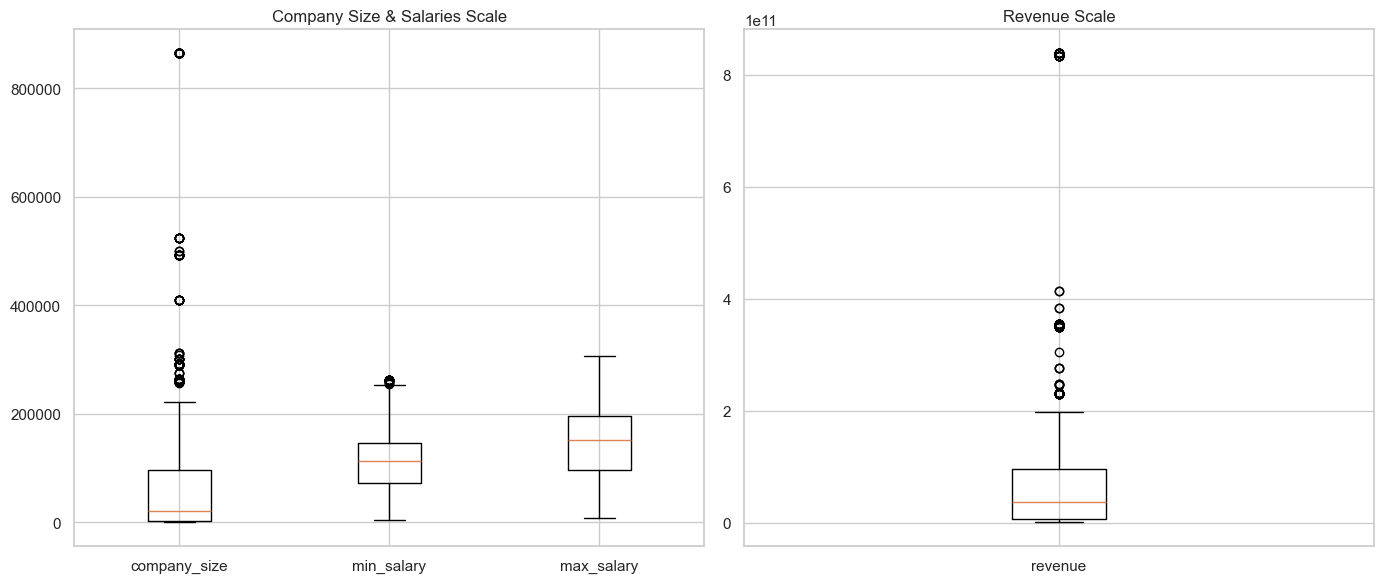

In [66]:
import matplotlib.pyplot as plt

# 1. Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 2. Left Plot: Company Size and Salaries (axes[0])
axes[0].boxplot(data[['company_size', 'min_salary', 'max_salary']], 
                labels=['company_size', 'min_salary', 'max_salary'])
axes[0].set_title('Company Size & Salaries Scale')

# 3. Right Plot: Revenue Scale Only (axes[1])
axes[1].boxplot(data['revenue'], labels=['revenue'])
axes[1].set_title('Revenue Scale')

# Automatically adjust spacing so text doesn't overlap
plt.tight_layout()
plt.show()


In [67]:

# Define the columns you want to clean
columns_to_clean = ['company_size', 'min_salary', 'max_salary', 'revenue']

# Create a copy to preserve original data
cleaned_data = data.copy()

for col in columns_to_clean:
    # Calculate Q1 (25th percentile) and Q3 (75th percentile)
    Q1 = cleaned_data[col].quantile(0.25)
    Q3 = cleaned_data[col].quantile(0.75)
    
    # Calculate the Interquartile Range
    IQR = Q3 - Q1
    
    # Define bounds (1.5 is the standard multiplier)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filter the dataframe to keep only values within the bounds
    cleaned_data = cleaned_data[(cleaned_data[col] >= lower_bound) & (cleaned_data[col] <= upper_bound)]

print(f"Original dataset rows: {len(data)}")
print(f"Cleaned dataset rows: {len(cleaned_data)}")


Original dataset rows: 933
Cleaned dataset rows: 695


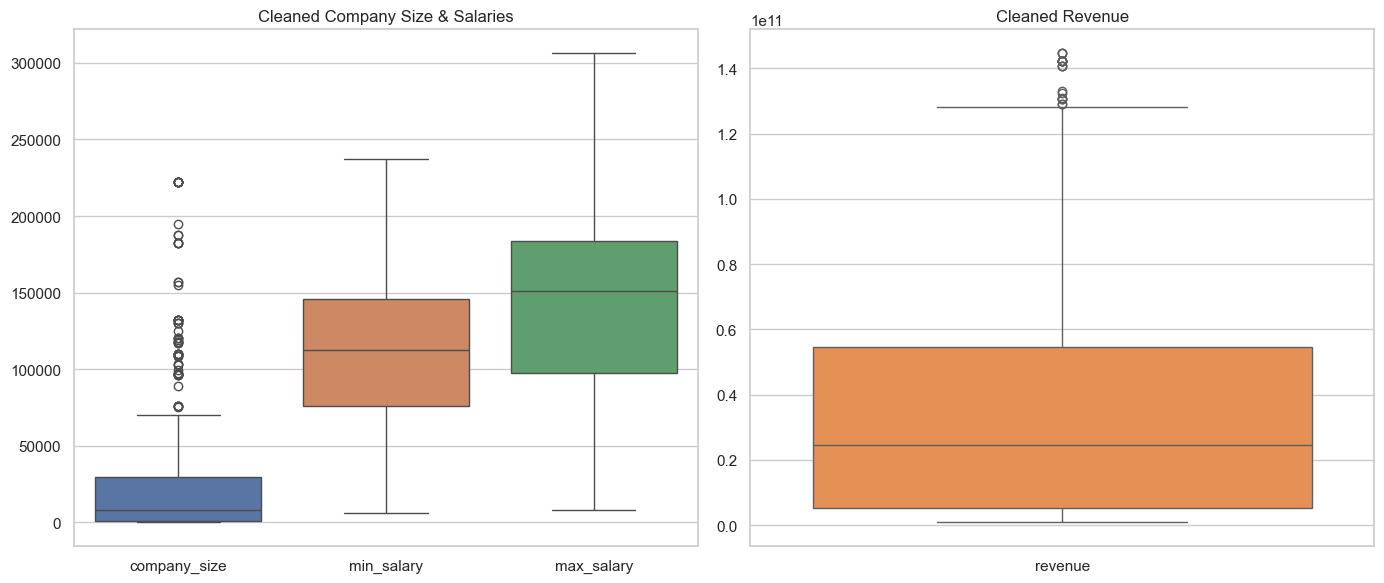

In [68]:
# Optional: Apply a clean, modern visual theme
sns.set_theme(style="whitegrid")

# 1. Create your 1-row, 2-column layout structure
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 2. Left Plot: Company Size and Salaries
# Passing the whole slice of data directly maps columns to boxes automatically
sns.boxplot(data=cleaned_data[['company_size', 'min_salary', 'max_salary']], ax=axes[0])
axes[0].set_title('Cleaned Company Size & Salaries')

# 3. Right Plot: Revenue (using a distinct color palette)
sns.boxplot(data=cleaned_data[['revenue']], ax=axes[1], palette="Oranges")
axes[1].set_title('Cleaned Revenue')

plt.tight_layout()
plt.show()


In [69]:
# Step 1: Clean hidden spaces from column names to prevent KeyErrors
data.columns = data.columns.str.strip()

# Step 2: Ensure 'Avg_salary' exists (creates it if missing or misspelled)
if 'Avg_salary' not in data.columns:
    # Check if a lowercase version exists, otherwise calculate it
    if 'avg_salary' in data.columns:
        data['Avg_salary'] = data['avg_salary']
    else:
        data['Avg_salary'] = (data['min_salary'] + data['max_salary']) / 2

# Step 3: Create Salary Groups (Bins)
# You can adjust these numbers based on your dataset's currency/ranges
salary_bins = [0, 50000, 100000, 150000, float('inf')]
salary_labels = ['Low (<50k)', 'Medium (50k-100k)', 'High (100k-150k)', 'Very High (150k+)']

data['salary_group'] = pd.cut(data['Avg_salary'], bins=salary_bins, labels=salary_labels)

# Step 4: Find the exact name of your location column
# (Assuming it is named 'location', 'Location', or 'job_location')
loc_col = [col for col in data.columns if 'loc' in col.lower()]
location_column_name = loc_col[0] if loc_col else 'location'

# Step 5: Create a parallel Crosstab Grid (Salary Group vs Location)
salary_location_grid = pd.crosstab(data[location_column_name], data['salary_group'])
print(salary_location_grid)


salary_group    Low (<50k)  Medium (50k-100k)  High (100k-150k)  \
location                                                          
Asia                   105                 28                 3   
Canada                   0                  9                11   
Europe                   8                 36                11   
Other                   10                 11                 4   
Remote                   0                  1                11   
United States            6                 52               216   
multi-location           7                 11                30   

salary_group    Very High (150k+)  
location                           
Asia                            3  
Canada                          4  
Europe                          3  
Other                           2  
Remote                         23  
United States                 290  
multi-location                 38  


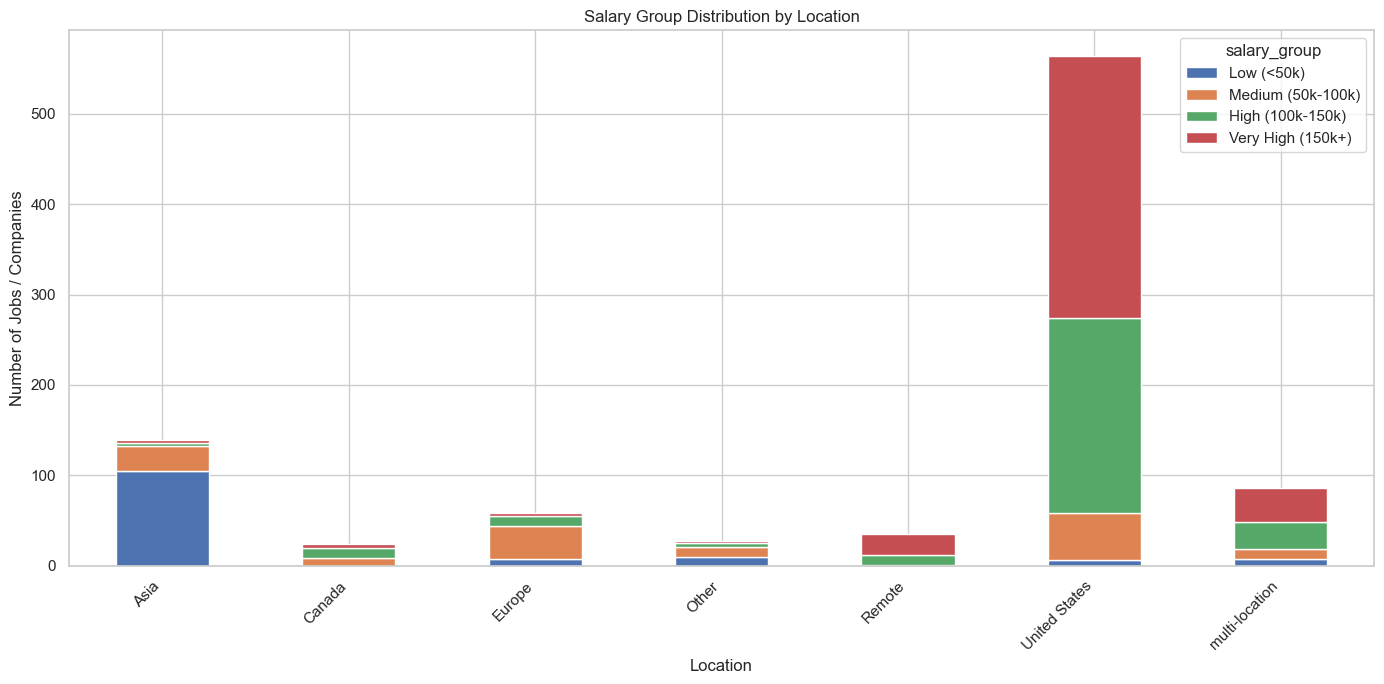

In [70]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# Plot the distribution of salary groups for each location
salary_location_grid.plot(kind='bar', stacked=True, figsize=(14, 7), ax=plt.gca())

plt.title('Salary Group Distribution by Location')
plt.xlabel('Location')
plt.ylabel('Number of Jobs / Companies')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Asian is the lowerst pay desnsity while USA is hishest pay density

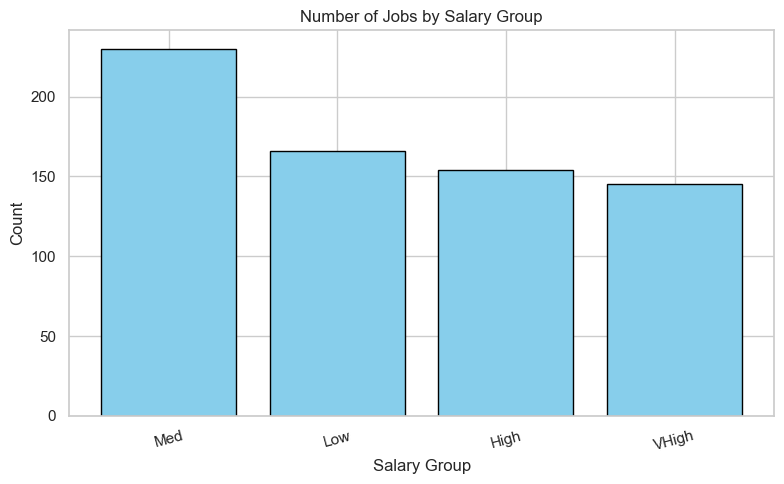

In [71]:
# 1. Count how many rows fall into each salary group
group_counts = cleaned_data['salary_group'].value_counts()

# 2. Plot the counts correctly
plt.figure(figsize=(8, 5))
plt.bar(group_counts.index, group_counts.values, color='skyblue', edgecolor='black')

plt.title('Number of Jobs by Salary Group')
plt.xlabel('Salary Group')
plt.ylabel('Count')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()


In [76]:
# Correct and clean:
Asian_USA_dataset = cleaned_data.loc[cleaned_data['location'].isin(['Asia', 'United States'])]
Asian_USA_dataset['location'].value_counts()

location
United States    432
Asia              80
Name: count, dtype: int64

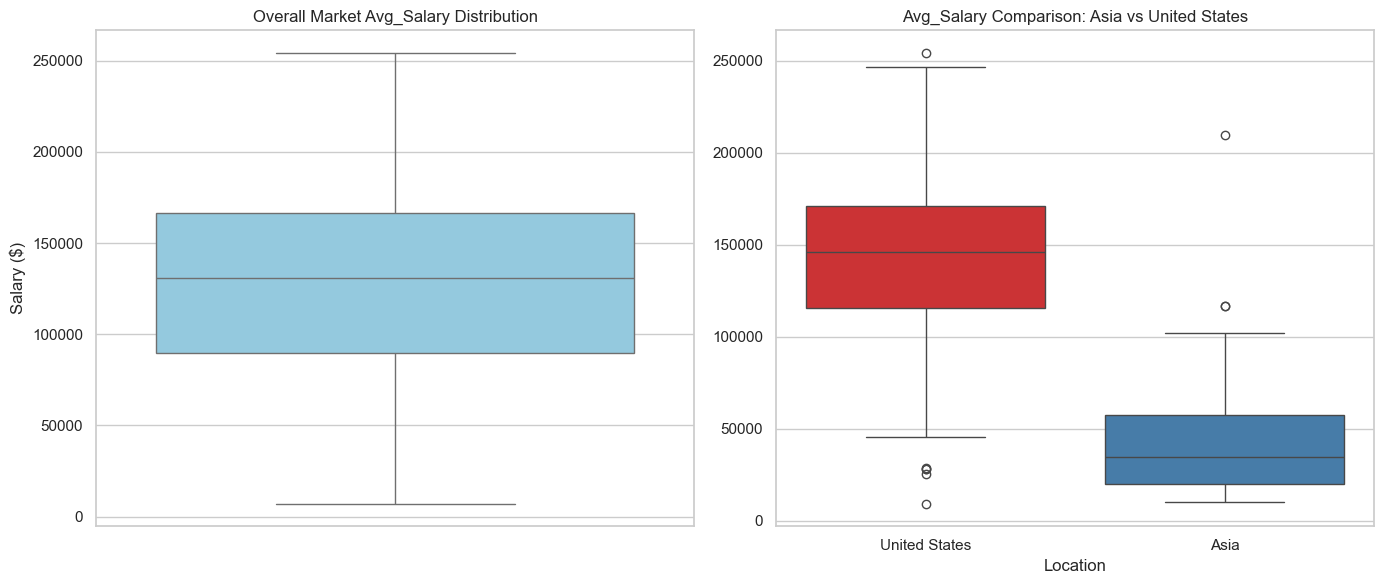

In [84]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: overall average salary
sns.boxplot(data=cleaned_data, y='Avg_Salary', ax=axes[0], color='skyblue')
axes[0].set_title('Overall Market Avg_Salary Distribution')
axes[0].set_ylabel('Salary ($)')

# Right: Asia vs United States
sns.boxplot(data=Asian_USA_dataset, x='location', y='Avg_Salary',
            hue='location', ax=axes[1], palette='Set1', legend=False)
axes[1].set_title('Avg_Salary Comparison: Asia vs United States')
axes[1].set_xlabel('Location')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

Data science salaries in the United States are significantly higher and have a much higher pay floor compared to Asia.
While the median salary in the United States sits around $145,000, the entire distribution box for Asia stays below $60,000, with its median hovering near $35,000. Furthermore, the United States market displays a wider spread of high-earning potential, whereas Asia's salaries remain heavily compressed at the lower end of the global spectrum.

jobs  avg_salary
location      seniority_level status  ownership                  
Asia          junior          hybrid  Public        2     32426.0
                              remote  Public        1     80381.0
              midlevel        hybrid  Private       1     83973.0
                                      Public        2     50924.0
                              on-site Private       2     40755.0
                                      Public        2     18197.0
                              remote  Private       1     80544.0
              senior          hybrid  Private      12     42984.0
                                      Public       24     36781.0
                              on-site Private       9     32741.0
                                      Public        5     27511.0
                              remote  Private       4     64242.0
                                      Public        4    105038.0
              lead            hybrid  Private       6     29476.0
                                      Public        3     29047.0
                              on-site Public        1     31351.0
                              remote  Public        1    101727.0
United States junior          on-site Private       5    159142.0
                                      Public        4    102892.0
                              remote  Public        1     78073.0
              midlevel        hybrid  Public        9    111454.0
                              on-site Private       5    133184.0
                                      Public       22    145820.0
                              remote  Private       2     62073.0
                                      Public        2     87558.0
              senior          hybrid  Private      37    153450.0
                                      Public       43    146614.0
                              on-site Private      82    151641.0
                                      Public      132    142033.0
                              remote  Private      15    146587.0
                                      Public       23    138690.0
              lead            hybrid  Private       7    178365.0
                                      Public        6    127379.0
                              on-site Private      18    158327.0
                                      Public       13    142102.0
                              remote  Private       1    179755.0
                                      Public        5    129970.0

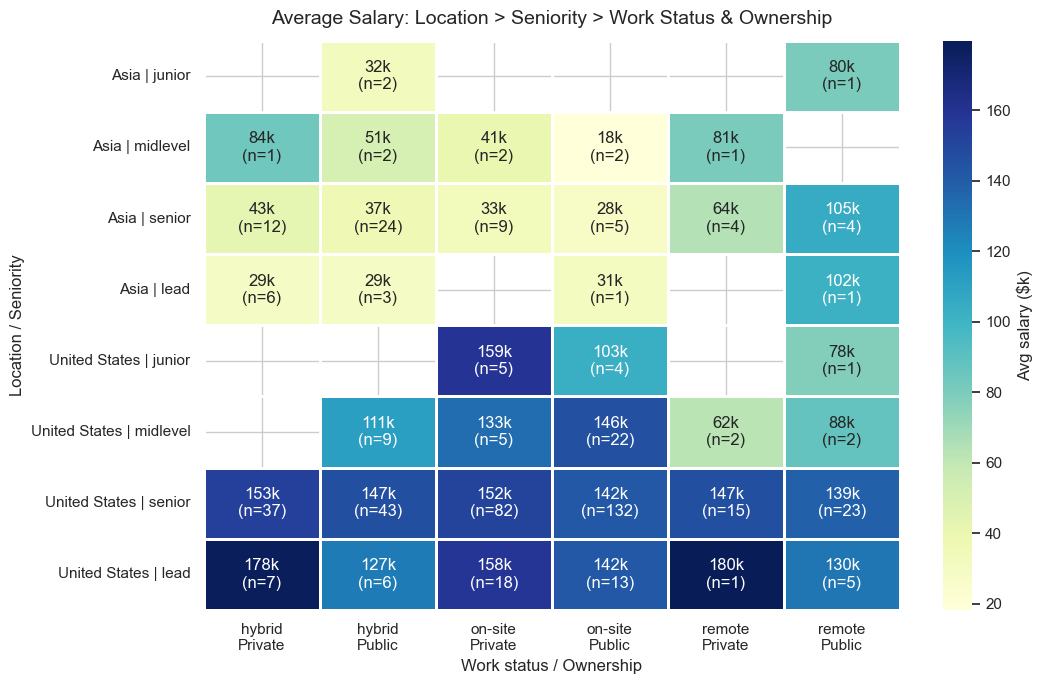

In [85]:

# ---- 1. Filter to Asia and United States ----
level_order = ['junior', 'midlevel', 'senior', 'lead']
sub = cleaned_data[cleaned_data['location'].isin(['Asia', 'United States'])].copy()
sub['seniority_level'] = pd.Categorical(sub['seniority_level'], level_order, ordered=True)

# ---- 2. Hierarchy table: location > seniority > status > ownership ----
hier = (sub.groupby(['location', 'seniority_level', 'status', 'ownership'], observed=True)
           .agg(jobs=('Avg_Salary', 'size'), avg_salary=('Avg_Salary', 'mean'))
           .round(0))
display(hier)

# ---- 3. Heatmap (one picture for the whole hierarchy) ----
sub['status_ownership'] = sub['status'] + '\n' + sub['ownership']

piv = sub.pivot_table(index=['location', 'seniority_level'], columns='status_ownership',
                      values='Avg_Salary', aggfunc='mean', observed=True)
cnt = sub.pivot_table(index=['location', 'seniority_level'], columns='status_ownership',
                      values='Avg_Salary', aggfunc='size', observed=True)

labels = (piv.round(-3).div(1000).round(0).astype('Int64').astype(str)
          + 'k\n(n=' + cnt.fillna(0).astype(int).astype(str) + ')')
labels = labels.where(piv.notna(), '')

fig, ax = plt.subplots(figsize=(11, 7))
sns.heatmap(piv / 1000, annot=labels, fmt='', cmap='YlGnBu',
            linewidths=1, linecolor='white', cbar_kws={'label': 'Avg salary ($k)'}, ax=ax)
ax.set_title('Average Salary: Location > Seniority > Work Status & Ownership', fontsize=14, pad=12)
ax.set_xlabel('Work status / Ownership')
ax.set_ylabel('Location / Seniority')
ax.set_yticklabels([f'{a} | {b}' for a, b in piv.index], rotation=0)
plt.tight_layout()
plt.show()

Senior form united States is the highest number. Total number is 132. but Asian-remote Public is 80K. this world be outlier.

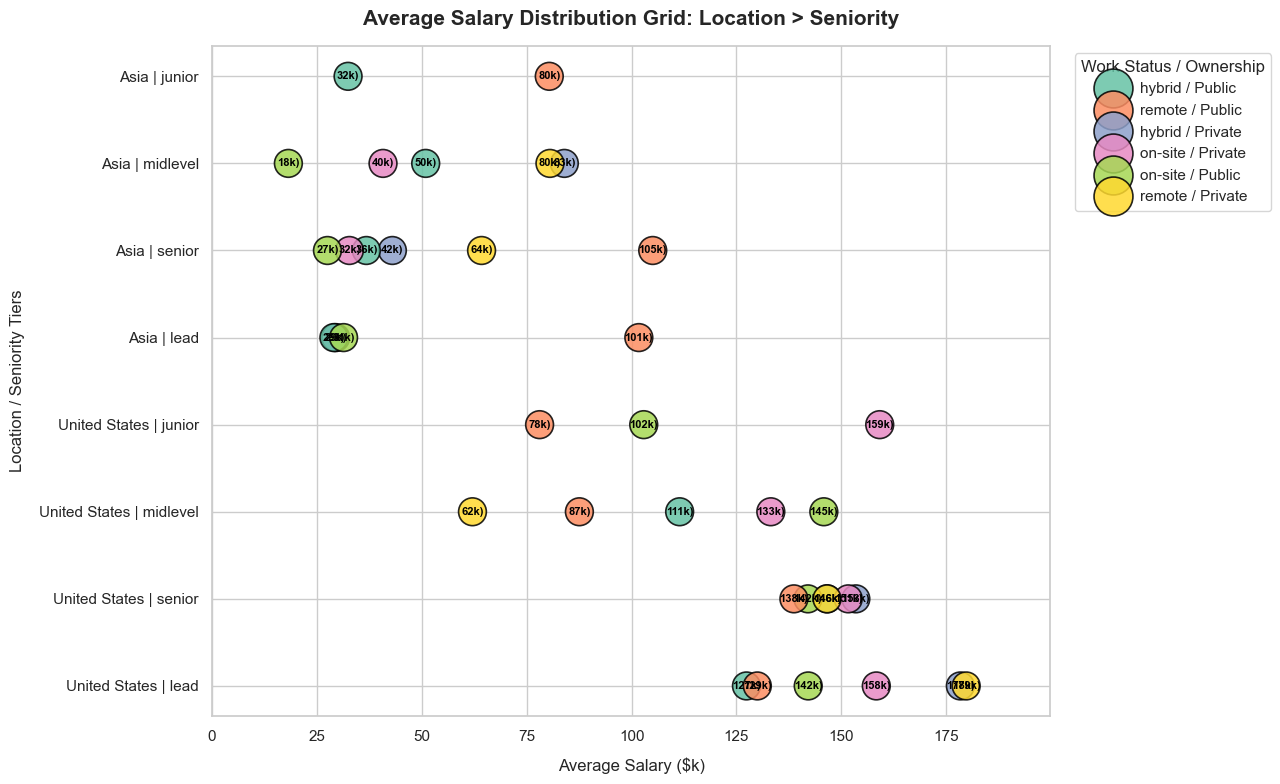

In [ ]:
# ---- 1. Flatten the hierarchy data for a scatter plot ----
# Reset the index of your 'hier' table to make it a flat DataFrame
scatter_df = hier.reset_index()

# Create matching combined string labels for the axes
scatter_df['location_seniority'] = scatter_df['location'] + ' | ' + scatter_df['seniority_level'].astype(str)
scatter_df['status_ownership'] = scatter_df['status'] + ' / ' + scatter_df['ownership']

# Convert salary to thousands ($k) to match your layout style
scatter_df['avg_salary_k'] = scatter_df['avg_salary'] / 1000

# Ensure the rows follow your custom seniority order ('junior' -> 'lead')
level_order = ['Asia | junior', 'Asia | midlevel', 'Asia | senior', 'Asia | lead',
               'United States | junior', 'United States | midlevel', 'United States | senior', 'United States | lead']
scatter_df['location_seniority'] = pd.Categorical(scatter_df['location_seniority'], categories=level_order, ordered=True)

# ---- 2. Build the Visual Plot ----
sns.set_theme(style="whitegrid")
plt.figure(figsize=(13, 8))

# Draw the circles extra large using s=250 and add a black edge contour ('edgecolor')
sns.scatterplot(
    data=scatter_df,
    x='avg_salary_k',
    y='location_seniority',
    hue='status_ownership',
    s=400,                  # Large circle size factor
    alpha=0.85,             # Slight transparency for overlapping points
    edgecolor='black',       # Sharp outline contrast
    linewidth=1.2,
    palette='Set2'          # Clean, modern categorical color palette
)

# ---- 3. Add Inline Value Text Annotations ----
# Loop through rows to overlay the specific '$k' salary strings directly inside/near the dots
for i, row in scatter_df.iterrows():
    if pd.notna(row['avg_salary_k']):
        plt.text(
            x=row['avg_salary_k'], 
            y=row['location_seniority'], 
            s=f"{int(row['avg_salary_k'])}k)",
            color='black', 
            fontsize=8, 
            weight='semibold',
            va='center', 
            ha='center'     # Centered text directly on top of the big circles
        )

# Grid styling details
plt.title('Average Salary Distribution Grid: Location > Seniority', fontsize=15, pad=15, weight='bold')
plt.xlabel('Average Salary ($k)', fontsize=12, labelpad=10)
plt.ylabel('Location / Seniority Tiers', fontsize=12, labelpad=10)
plt.xlim(0, scatter_df['avg_salary_k'].max() + 20) # Give padding on the right for text labels

# Move the legend outside so it doesn't overlap any big data points
plt.legend(title='Work Status / Ownership', bbox_to_anchor=(1.02, 1), loc='upper left', markerscale=1.4)

plt.tight_layout()
plt.show()


The chart reveals that geographic location is the primary driver of salary variance, with the United States possessing a significantly higher pay floor than Asia across all seniority levels. Within both regions, Remote / Public corporate structures systematically command the highest premium, frequently allowing flexible roles to out-earn traditional on-site positions regardless of experience. Conversely, On-site / Private settings consistently anchor the lowest end of the compensation spectrum, making structural flexibility and corporate governance more influential factors in maximizing salary than traditional career progression tags alone.


In [91]:
import ast

# Convert strings to lists, flatten them all together, and count occurrences
flattened_skills = cleaned_data['skills'].dropna().apply(lambda x: ast.literal_eval(x) if isinstance(x, str) and x.startswith('[') else [])
skill_counts = pd.Series([skill for sublist in flattened_skills for skill in sublist]).value_counts()

print(skill_counts)


python              452
machine learning    412
sql                 312
r                   215
aws                 159
deep learning       131
tensorflow          111
spark               109
azure               107
pytorch             102
tableau              93
gcp                  75
scikit-learn         73
database             65
pandas               59
git                  55
java                 47
hadoop               45
numpy                44
scala                39
docker               39
kubernetes           32
matplotlib           25
powerbi              23
keras                22
airflow              22
amazon               19
linux                19
neural network       10
scipy                 7
sklearn               5
bash                  1
opencv                1
Name: count, dtype: int64


C:\Users\USER\AppData\Local\Temp\ipykernel_8476\345720748.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=frequencies, y=skills_names, palette="viridis", edgecolor='black', linewidth=1)


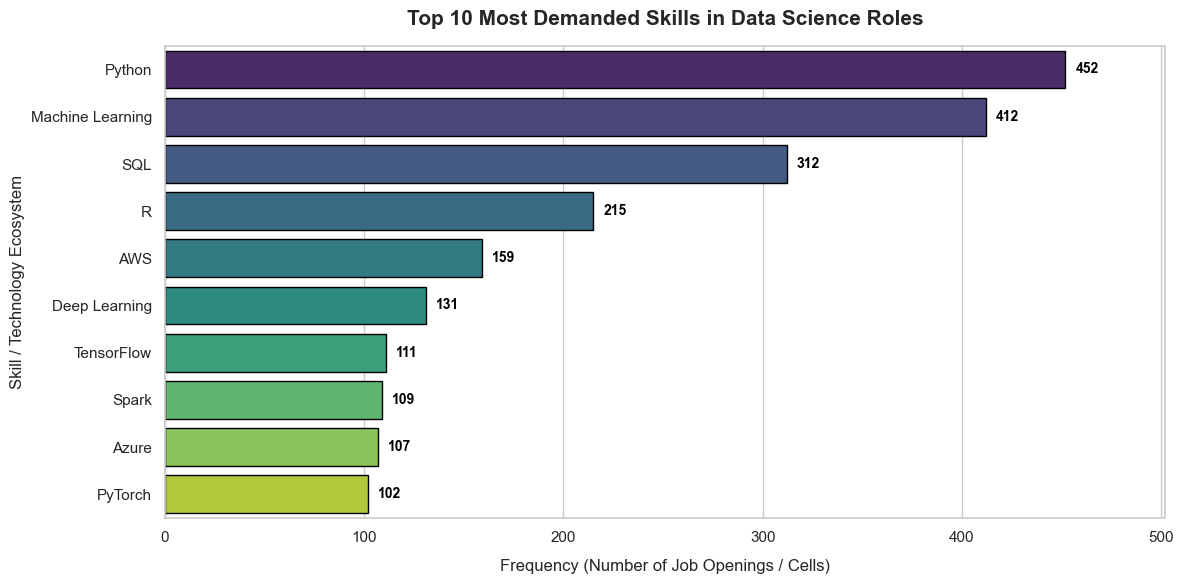

In [92]:

# 1. Create a data structure from your frequency results
top_10_skills = {
    'Python': 452,
    'Machine Learning': 412,
    'SQL': 312,
    'R': 215,
    'AWS': 159,
    'Deep Learning': 131,
    'TensorFlow': 111,
    'Spark': 109,
    'Azure': 107,
    'PyTorch': 102
}

# Convert the dictionary keys and values into standalone tracking variables
skills_names = list(top_10_skills.keys())
frequencies = list(top_10_skills.values())

# 2. Set up the plotting window grid using Seaborn styling defaults
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 3. Create the horizontal bar plot
# Passing frequencies to x and names to y keeps the categories readable on the left margin
ax = sns.barplot(x=frequencies, y=skills_names, palette="viridis", edgecolor='black', linewidth=1)

# 4. Inline annotations: overlay frequency numbers directly on top of the bars
for i, val in enumerate(frequencies):
    ax.text(val + 5, i, f'{val}', va='center', ha='left', fontsize=10, weight='semibold', color='black')

# Labeling and polish adjustments
plt.title('Top 10 Most Demanded Skills in Data Science Roles', fontsize=15, pad=15, weight='bold')
plt.xlabel('Frequency (Number of Job Openings / Cells)', fontsize=12, labelpad=10)
plt.ylabel('Skill / Technology Ecosystem', fontsize=12)

# Give a bit of safety margin padding on the right axis so values don't clip
plt.xlim(0, max(frequencies) + 50)

plt.tight_layout()
plt.show()


Python, Machine Learning, and SQL are the top three most demanded skills in data science job roles.
